In [1]:
%load_ext autoreload
%autoreload 2

# Imports / インポート

This notebook imports reusable modules that handle each stage of the HAR pipeline.

このノートブックでは、HAR パイプラインの各処理を担当するモジュールを読み込みます。

### Modules Included / 読み込むモジュール
- Data loading / データ読み込み
- Configuration / 設定
- Preprocessing / 前処理
- Feature engineering / 特徴量生成
- Model evaluation / モデル評価
- Visualization / 可視化

In [1]:
# ==========================================================
# Import project modules / プロジェクトモジュールの読み込み
# ==========================================================

# Load utility functions for reading datasets and formatting notebook output
# データセットの読み込みとノートブック出力を整形するユーティリティ
from har_utils.data import (
    get_subject,
    get_clean_header
)

# Load global configuration values shared across the project
# プロジェクト全体で使用する設定値を読み込む
from har_utils.config import FILE_NAME_SUFFIX

# Load preprocessing functions for data cleaning and feature preparation
# データクリーニングと特徴量生成前処理を行う関数
from har_utils.preprocessing import (
    do_sanity_check,
    preprocessing_pipeline
)

# Load visualization utilities for model analysis and result inspection
# モデルの分析や結果を可視化するためのユーティリティ
from har_utils.visualization import (
    plot_confusion_matrix,
    plot_feature_class_across_subjects
)

# Load machine learning model constructors
# 機械学習モデルを生成する関数
from har_utils.model import model_random_forest

# Load feature engineering functions for pose-based descriptors
# 姿勢情報から特徴量を生成する関数
from har_utils.features import (
    add_angle_features,
    create_windowed_features,
    add_range_of_motion_features
)

# Load evaluation utilities for training and performance analysis
# モデルの学習および性能評価を行う関数
from har_utils.analysis import (
    preprocess_evaluate_random_forest,
    evaluate_loso,
    get_feature_importance
)

# Save and load trained machine learning models
# 学習済みモデルの保存と読み込み
import joblib

# Generate reproducible random values
# 再現性のある乱数を生成
import random as rnd

# Data manipulation and tabular processing
# データフレームの操作および処理
import pandas as pd

## Load Dataset / データセットの読み込み

Load the pose estimation data for each subject into a dictionary, where the subject ID is used as the key. Display the shape of each dataset to verify that all files were loaded successfully.

各被験者の姿勢推定データを辞書に読み込み、被験者IDをキーとして管理します。あわせて各データセットのサイズを表示し、正しく読み込まれたことを確認します。

In [3]:
# Load all subject datasets into a dictionary for easy access
# 各被験者のデータセットを辞書に読み込み、一括管理する
all_subject = {}

for suffix in FILE_NAME_SUFFIX:

    # Read the current subject dataset from the CSV file
    # 現在の被験者データをCSVファイルから読み込む
    all_subject[suffix] = get_subject(suffix)

    # Display the dataset dimensions to verify successful loading
    # データが正しく読み込まれたか、データサイズを確認する
    print(f"Subject_{suffix} Shape: {all_subject[suffix].shape}")

Subject_1 Shape: (76456, 35)
Subject_2 Shape: (74638, 35)
Subject_3 Shape: (118087, 35)
Subject_5 Shape: (75981, 35)


## Data Sanity Check / データの健全性確認

Inspect each subject dataset before preprocessing to identify missing values, invalid entries, or other data quality issues.

前処理を行う前に、各被験者データを確認し、欠損値や異常値などのデータ品質の問題がないかを確認します。

In [4]:
# Perform a sanity check on each subject dataset before preprocessing
# 前処理を行う前に、各被験者データの整合性を確認する
for suffix in FILE_NAME_SUFFIX:

    # Check for missing values, invalid values, and dataset consistency
    # 欠損値・異常値・データの整合性を確認する
    do_sanity_check(all_subject[suffix], f"Subject_{suffix}")


____________________________________________________________

               Sanity Check - Subject_1
____________________________________________________________

NaN counts:
  Action Label: 3406

Inf counts:

____________________________________________________________

               Sanity Check - Subject_2
____________________________________________________________

NaN counts:
  Action Label: 3388

Inf counts:

____________________________________________________________

               Sanity Check - Subject_3
____________________________________________________________

NaN counts:
  Action Label: 11617

Inf counts:

____________________________________________________________

               Sanity Check - Subject_5
____________________________________________________________

NaN counts:
  Action Label: 4161

Inf counts:


## Data Preprocessing & Feature Engineering / データ前処理・特徴量生成

The preprocessing pipeline performs the following operations.

前処理パイプラインでは、以下の処理を実行します。

### Data Cleaning / データクリーニング
- Remove samples with missing activity labels.
- Normalize skeleton coordinates using the hip joint as the origin.
- Remove invalid frames with insufficient shoulder width.
- Standardize inconsistent activity labels.

- アクティビティラベルが欠損したサンプルを除去
- 股関節を基準として骨格座標を正規化
- 肩幅が閾値未満の無効フレームを除去
- 表記が異なるアクティビティラベルを統一

### Feature Engineering / 特徴量生成
- Compute joint angle features.
- Compute range-of-motion features.
- Compute velocity and acceleration features.

- 関節角度特徴量を計算
- 可動域（Range of Motion）特徴量を計算
- 速度および加速度特徴量を計算

### Temporal Aggregation / 時系列特徴量生成
- Combine all frame-level features into a single dataset.
- Generate multi-scale windowed features using 15-frame and 60-frame windows.

- フレーム単位の特徴量を統合
- 15フレームと60フレームのマルチスケール時間窓特徴量を生成

### Output / 出力
- Display summary statistics for Subject 1 as a representative example.
- 代表例として Subject 1 の前処理結果を表示

In [6]:
# Apply the preprocessing pipeline to every subject dataset
# 各被験者データに前処理パイプラインを適用する
all_subject_norm = {}

for suffix in FILE_NAME_SUFFIX:

    # Execute preprocessing to generate normalized, windowed feature data
    # 前処理を実行し、正規化およびウィンドウ化された特徴量を生成する
    all_subject_norm[suffix] = preprocessing_pipeline(all_subject[suffix])

    # Display summary statistics for one representative subject
    # 代表例として1名分の前処理結果を表示する
    if suffix == '1':
        print(f"Subject_{suffix} Shape: {all_subject_norm[suffix].shape}")
        print(f"Description of Subject_{suffix}:\n{all_subject_norm[suffix].describe().T.round(2)}")
        print(f"Number of features: {len(all_subject_norm[suffix].columns) - 1}")

Subject_1 Shape: (7073, 945)
Description of Subject_1:
                             count  mean   std   min   25%   50%   75%   max
short_nose_x_mean           7073.0 -0.00  0.40 -1.63 -0.41  0.08  0.28  1.47
short_nose_y_mean           7073.0 -1.28  0.23 -1.59 -1.41 -1.36 -1.28  1.63
short_left_eye_x_mean       7073.0  0.01  0.40 -1.60 -0.36  0.10  0.28  1.56
short_left_eye_y_mean       7073.0 -1.37  0.23 -1.67 -1.50 -1.46 -1.36  1.53
short_right_eye_x_mean      7073.0 -0.08  0.40 -1.73 -0.43 -0.05  0.23  1.46
...                            ...   ...   ...   ...   ...   ...   ...   ...
long_left_ankle_y_acc_max   7073.0  0.11  0.31  0.01  0.03  0.06  0.11  7.23
long_right_ankle_x_vel_max  7073.0  0.09  0.14  0.01  0.02  0.04  0.09  1.05
long_right_ankle_x_acc_max  7073.0  0.12  0.19  0.01  0.03  0.05  0.11  2.12
long_right_ankle_y_vel_max  7073.0  0.09  0.26  0.00  0.02  0.04  0.09  7.26
long_right_ankle_y_acc_max  7073.0  0.11  0.32  0.01  0.03  0.06  0.10  7.85

[944 rows x 8 column

## Model Training & Evaluation / モデル学習・評価

Train a Random Forest classifier and evaluate its performance using Leave-One-Subject-Out (LOSO) cross-validation.

Random Forest 分類器を学習し、Leave-One-Subject-Out（LOSO）交差検証を用いて性能を評価します。

### Evaluation Setup / 評価設定
- Window sizes: 15 and 60 frames
- Classifier: Random Forest
- Evaluation method: Leave-One-Subject-Out (LOSO)
- Performance metric: Macro F1-score
       
- 時間窓サイズ：15フレーム・60フレーム
- 分類器：Random Forest
- 評価手法：Leave-One-Subject-Out（LOSO）
- 評価指標：Macro F1-score

In [7]:
# Display the current temporal window size used for feature extraction
# 特徴量生成に使用する時間窓サイズを表示する
get_clean_header("Window Size: (15, 60)")

# Create a Random Forest classifier with the predefined configuration
# 設定済みのRandom Forest分類器を作成する
model = model_random_forest()

# Evaluate the model using Leave-One-Subject-Out (LOSO) cross-validation
# Leave-One-Subject-Out（LOSO）交差検証でモデルを評価する
result = evaluate_loso(all_subject_norm, model)


                             Window Size: (15, 60)                              

────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.77      0.10      0.18
  Biting                      0.00      0.00      0.00
  Eating snacks               0.26      0.70      0.38
  Head banging                1.00      0.65      0.79
  Sitting quietly             0.01      0.00      0.00
  Throwing things             0.49      0.75      0.59
  Using phone                 0.67      0.00      0.00
  Walking                     0.83      1.00      0.91

  Macro F1: 0.356

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  Class                  Precis

In [13]:
get_clean_header("Window Size of (15, 90)")
result = preprocess_evaluate_random_forest(all_subject, (15, 90))


                            Window Size of (15, 90)                             

────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.07      0.11      0.09
  Biting                      0.00      0.00      0.00
  Eating snacks               0.39      0.79      0.53
  Head banging                0.23      0.58      0.33
  Sitting quietly             0.00      0.00      0.00
  Throwing things             0.49      0.74      0.59
  Using phone                 0.00      0.00      0.00
  Walking                     0.82      1.00      0.90

  Macro F1: 0.305

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  Class                  Precis

In [14]:
get_clean_header("Window Size of (15, 120)")
result = preprocess_evaluate_random_forest(all_subject, (15, 120))


                            Window Size of (15, 120)                            

────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.71      0.09      0.17
  Biting                      0.00      0.00      0.00
  Eating snacks               0.39      0.73      0.51
  Head banging                0.18      0.76      0.29
  Sitting quietly             0.04      0.01      0.02
  Throwing things             0.58      0.85      0.69
  Using phone                 0.00      0.00      0.00
  Walking                     0.84      1.00      0.91

  Macro F1: 0.324

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  Class                  Precis


════════════════════════════════════════════════════
  TOP 60 FEATURE IMPORTANCES
════════════════════════════════════════════════════
  Rank   Feature                                  Importance
  ────── ──────────────────────────────────────── ──────────
  1      long_min_wrist_to_nose_dist_min              0.0119
  2      long_min_wrist_to_nose_dist_mean             0.0110
  3      long_right_wrist_y_min                       0.0102
  4      long_min_wrist_height_rel_shoulder_min       0.0099
  5      long_right_wrist_to_nose_dist_min            0.0099
  6      short_min_wrist_to_nose_dist_max             0.0097
  7      long_right_wrist_height_rel_shoulder_min     0.0089
  8      long_left_wrist_x_std                        0.0089
  9      long_angle_right_shoulder_max                0.0085
  10     long_right_wrist_height_rel_hip_min          0.0084
  11     long_min_wrist_height_rel_shoulder_mean      0.0080
  12     long_angle_right_shoulder_std                0.0080
  13     l

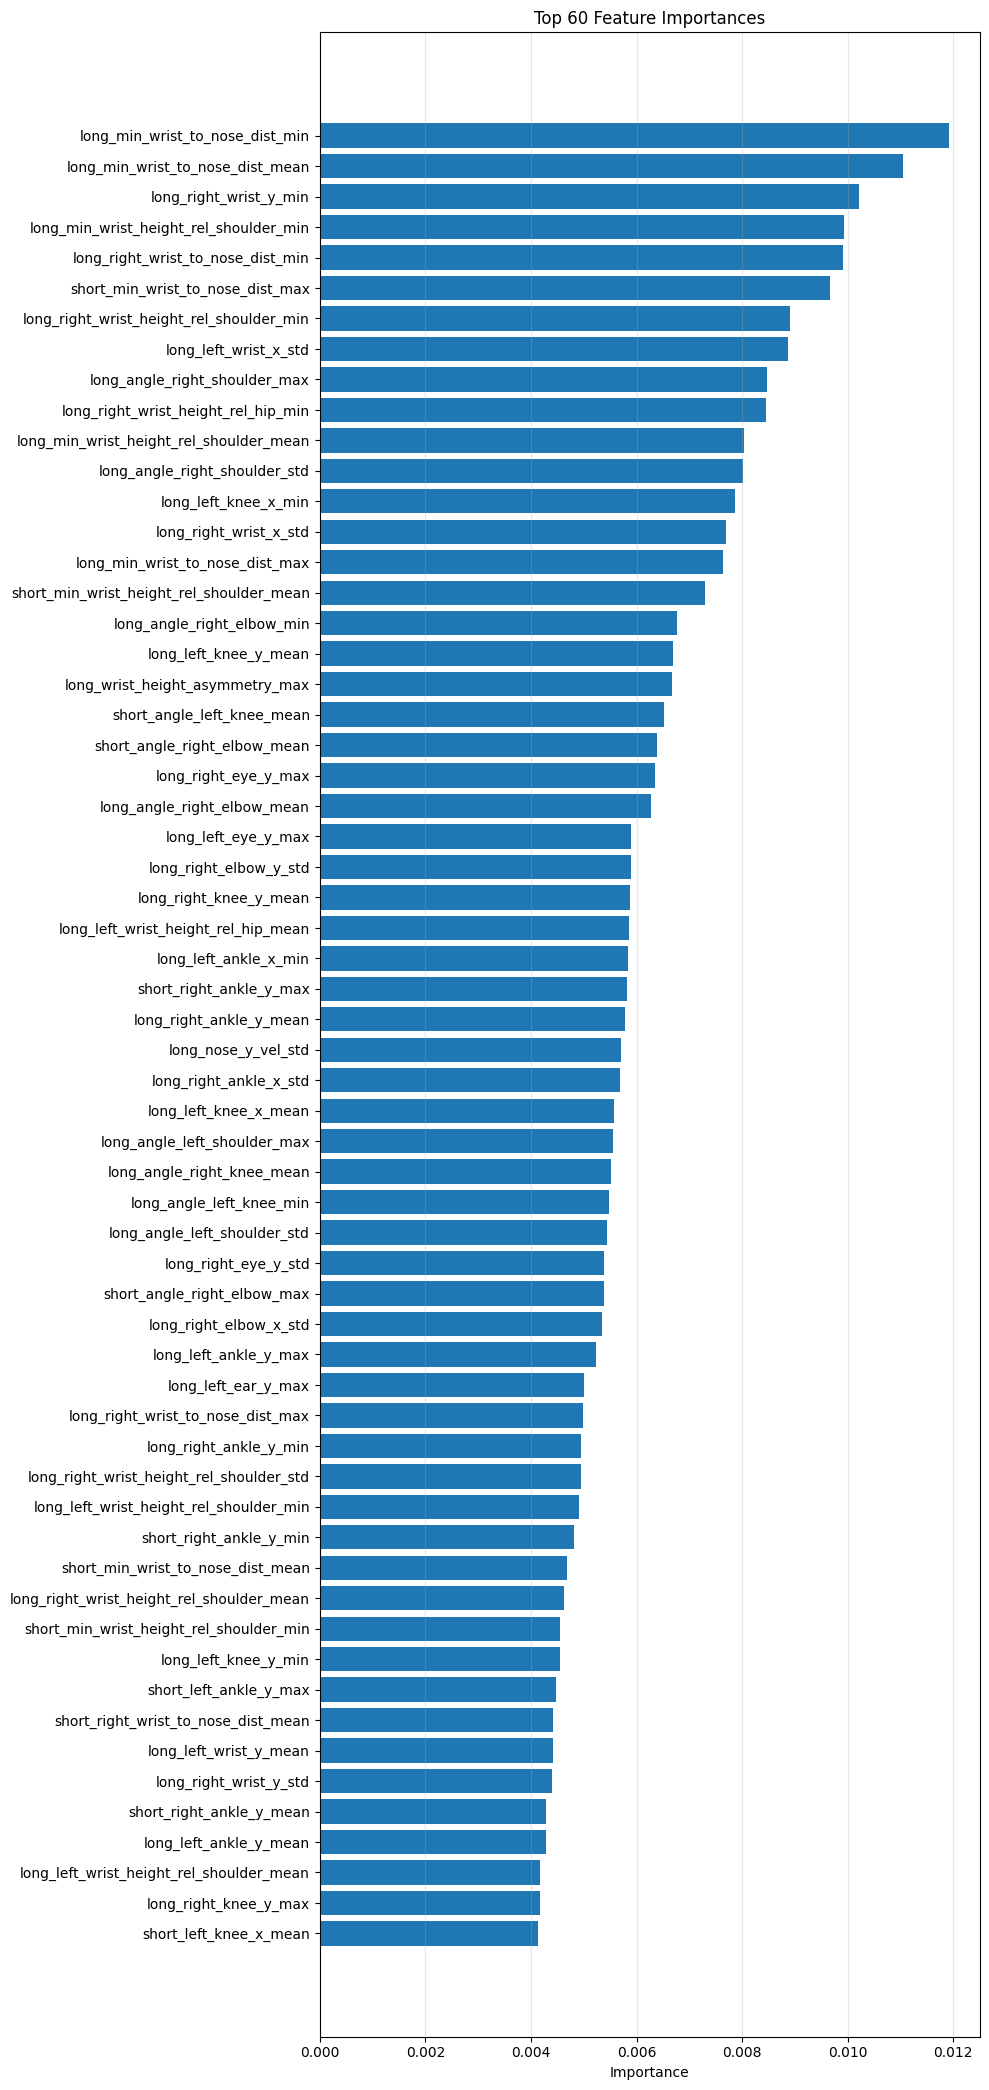

In [11]:
importance_df = get_feature_importance(all_subject_norm, top_n=60)

In [2]:
def filter_features_by_importance(all_subjects, importance_df, top_n=150, label_col='Action Label'):
    """
    Filters all subject DataFrames to keep only the top N most important features.

    Parameters
    ----------
    all_subjects : dict
        Keys are subject IDs, values are windowed DataFrames.
    importance_df : pd.DataFrame
        Output of get_feature_importance() — must have a 'feature' column
        sorted by importance descending.
    top_n : int
        Number of top features to keep.
    label_col : str
        Label column — always kept regardless of importance.

    Returns
    -------
    dict
        Same structure as all_subjects but with only top_n features + label.
    """
    top_features = importance_df['feature'].head(top_n).tolist()

    # Always include the label column
    cols_to_keep = top_features + [label_col]

    filtered = {}
    for subject_id, df in all_subjects.items():
        # Only keep columns that actually exist in this df
        # (guards against any mismatch between importance_df and subject columns)
        available = [c for c in cols_to_keep if c in df.columns]
        filtered[subject_id] = df[available].copy()

    print(f"Features kept: {top_n}")
    print(f"Features dropped: {len(importance_df) - top_n}")
    print(f"Subjects processed: {list(filtered.keys())}")

    return filtered


════════════════════════════════════════════════════
  TOP 60 FEATURE IMPORTANCES
════════════════════════════════════════════════════
  Rank   Feature                                  Importance
  ────── ──────────────────────────────────────── ──────────
  1      long_min_wrist_to_nose_dist_min              0.0119
  2      long_min_wrist_to_nose_dist_mean             0.0110
  3      long_right_wrist_y_min                       0.0102
  4      long_min_wrist_height_rel_shoulder_min       0.0099
  5      long_right_wrist_to_nose_dist_min            0.0099
  6      short_min_wrist_to_nose_dist_max             0.0097
  7      long_right_wrist_height_rel_shoulder_min     0.0089
  8      long_left_wrist_x_std                        0.0089
  9      long_angle_right_shoulder_max                0.0085
  10     long_right_wrist_height_rel_hip_min          0.0084
  11     long_min_wrist_height_rel_shoulder_mean      0.0080
  12     long_angle_right_shoulder_std                0.0080
  13     l

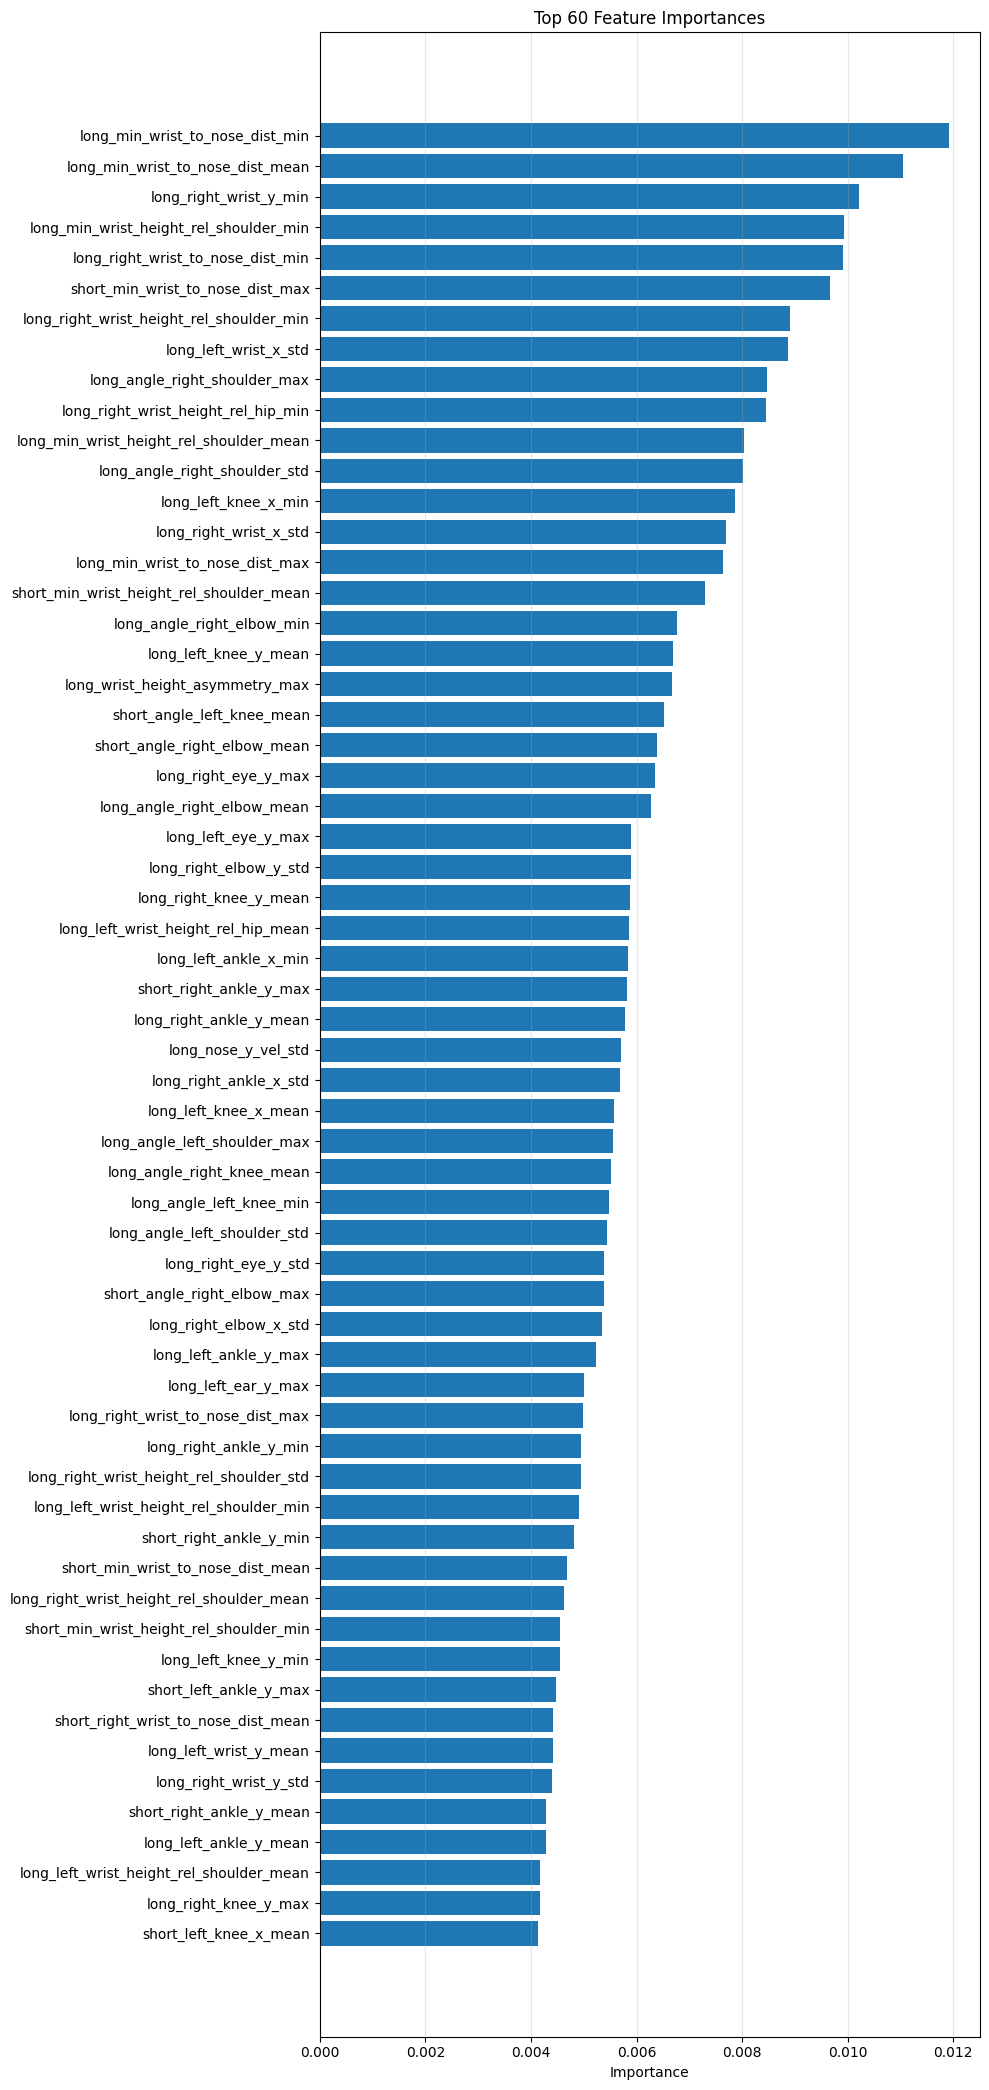


  TESTING TOP 100 FEATURES
Features kept: 100
Features dropped: 844
Subjects processed: ['1', '2', '3', '5']

────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.39      0.24      0.30
  Biting                      0.00      0.00      0.00
  Eating snacks               0.38      0.98      0.55
  Head banging                1.00      0.78      0.87
  Sitting quietly             0.98      0.50      0.66
  Throwing things             0.48      0.49      0.49
  Using phone                 0.33      0.01      0.01
  Walking                     0.85      1.00      0.92

  Macro F1: 0.475

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  C

In [13]:
# Generate importances on your full feature set
importance_df = get_feature_importance(all_subject_norm, top_n=20)

# Try three different cutoffs
for top_n in [100, 150, 200]:
    print(f"\n{'='*52}")
    print(f"  TESTING TOP {top_n} FEATURES")
    print(f"{'='*52}")
    
    filtered_subjects = filter_features_by_importance(
        all_subject_norm,
        importance_df,
        top_n=top_n
    )
    
    results = evaluate_random_forest_loso(filtered_subjects);


════════════════════════════════════════════════════
  TOP 10 FEATURE IMPORTANCES
════════════════════════════════════════════════════
  Rank   Feature                                  Importance
  ────── ──────────────────────────────────────── ──────────
  1      long_min_wrist_to_nose_dist_min              0.0119
  2      long_min_wrist_to_nose_dist_mean             0.0110
  3      long_right_wrist_y_min                       0.0102
  4      long_min_wrist_height_rel_shoulder_min       0.0099
  5      long_right_wrist_to_nose_dist_min            0.0099
  6      short_min_wrist_to_nose_dist_max             0.0097
  7      long_right_wrist_height_rel_shoulder_min     0.0089
  8      long_left_wrist_x_std                        0.0089
  9      long_angle_right_shoulder_max                0.0085
  10     long_right_wrist_height_rel_hip_min          0.0084
════════════════════════════════════════════════════



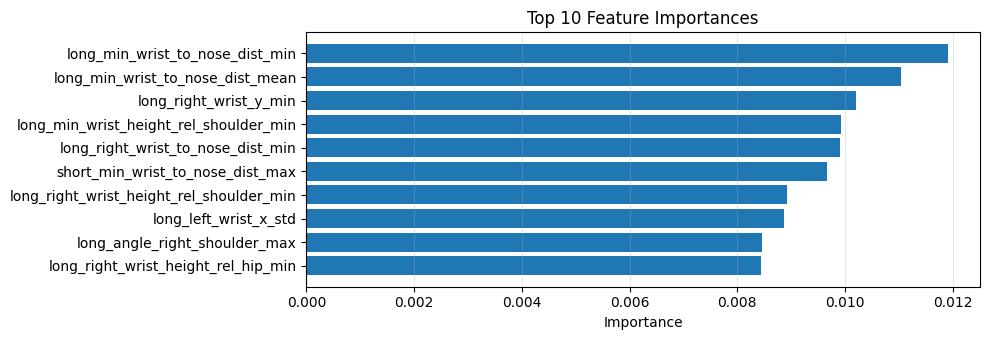


  TESTING TOP 100 FEATURES
Features kept: 100
Features dropped: 844
Subjects processed: ['1', '2', '3', '5']

────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.11      0.19      0.14
  Biting                      0.00      0.00      0.00
  Eating snacks               0.42      0.85      0.56
  Head banging                0.95      0.38      0.54
  Sitting quietly             0.66      0.47      0.55
  Throwing things             0.48      0.53      0.50
  Using phone                 0.96      0.07      0.14
  Walking                     0.79      0.99      0.88

  Macro F1: 0.414

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  C

In [12]:
# Generate importances on your full feature set
importance_df = get_feature_importance(all_subject_norm, top_n=10)

# Try three different cutoffs
for top_n in [100, 150, 200]:
    print(f"\n{'='*52}")
    print(f"  TESTING TOP {top_n} FEATURES")
    print(f"{'='*52}")
    
    filtered_subjects = filter_features_by_importance(
        all_subject_norm,
        importance_df,
        top_n=top_n
    )
    
    results = evaluate_loso(filtered_subjects, 'hist-gradient');

# Optuna

In [18]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from tqdm import tqdm
import pandas as pd
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)


def optuna_objective_loso(trial, all_subjects, label_col='Action Label'):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth':         trial.suggest_categorical('max_depth', [5, 10, 20, 30, None]),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        'random_state': 42,
        'n_jobs': -1
    }

    subject_ids = list(all_subjects.keys())
    fold_scores = []

    for test_subject in subject_ids:
        train_subjects = [s for s in subject_ids if s != test_subject]

        train_df = pd.concat(
            [all_subjects[s] for s in train_subjects],
            ignore_index=True
        )
        test_df = all_subjects[test_subject]

        X_train = train_df.drop(columns=[label_col])
        y_train = train_df[label_col]
        X_test  = test_df.drop(columns=[label_col])
        y_test  = test_df[label_col]

        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        fold_scores.append(
            f1_score(y_test, preds, average='macro', zero_division=0)
        )

    return np.mean(fold_scores)


def run_optuna_study(all_subjects, n_trials=50, label_col='Action Label'):
    study = optuna.create_study(
        direction='maximize',
        study_name='rf_loso_tuning',
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    print(f"\n{'═' * 58}")
    print(f"  OPTUNA SEARCH  —  {n_trials} trials  |  4 LOSO folds each")
    print(f"{'═' * 58}\n")

    # tqdm bar — one tick per completed trial
    progress_bar = tqdm(
        total=n_trials,
        desc='Tuning',
        unit='trial',
        bar_format='{desc}: {percentage:3.0f}%|{bar}| {n}/{total} '
                   '[{elapsed}<{remaining}, {rate_fmt}]'
    )

    best_so_far = [0.0]  # list so the closure can mutate it

    def callback(study, trial):
        # Update best tracker
        if trial.value > best_so_far[0]:
            best_so_far[0] = trial.value

        # Update the bar's suffix with live stats
        progress_bar.set_postfix({
            'current': f'{trial.value:.4f}',
            'best':    f'{best_so_far[0]:.4f}'
        })
        progress_bar.update(1)

    study.optimize(
        lambda trial: optuna_objective_loso(trial, all_subjects, label_col),
        n_trials=n_trials,
        callbacks=[callback]
    )

    progress_bar.close()

    # ── Summary ───────────────────────────────────────────────────
    print(f"\n{'═' * 58}")
    print(f"  BEST RESULT")
    print(f"{'═' * 58}")
    print(f"  Mean LOSO Macro F1 : {study.best_value:.4f}")
    print(f"  Best trial number  : {study.best_trial.number}")
    print(f"\n  Best Parameters:")
    for param, value in study.best_params.items():
        print(f"    {param:<25} {value}")
    print(f"{'═' * 58}\n")

    return study

In [19]:
# Run on your best configuration — top 100 features
filtered_100 = filter_features_by_importance(
    all_subject_norm, importance_df, top_n=100
)

study = run_optuna_study(filtered_100, n_trials=50)

Features kept: 100
Features dropped: 844
Subjects processed: ['1', '2', '3', '5']

══════════════════════════════════════════════════════════
  OPTUNA SEARCH  —  50 trials  |  4 LOSO folds each
══════════════════════════════════════════════════════════



Tuning: 100%|████████████████████████████████████████████████████| 50/50 [33:35<00:00, 40.31s/trial]


══════════════════════════════════════════════════════════
  BEST RESULT
══════════════════════════════════════════════════════════
  Mean LOSO Macro F1 : 0.5542
  Best trial number  : 43

  Best Parameters:
    n_estimators              400
    max_depth                 10
    min_samples_leaf          21
    min_samples_split         4
    max_features              log2
══════════════════════════════════════════════════════════



In [22]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

results = evaluate_loso(filtered_100, model_param=best_model, model_type=None);


────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.44      0.25      0.32
  Biting                      0.00      0.00      0.00
  Eating snacks               0.57      1.00      0.72
  Head banging                0.98      0.67      0.79
  Sitting quietly             0.87      0.97      0.92
  Throwing things             0.49      0.53      0.51
  Using phone                 1.00      0.32      0.49
  Walking                     0.83      0.99      0.91

  Macro F1: 0.582

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  A

# Experiment Results Summary

## Evaluation Methodology
- **Dataset**: 4 subjects performing 8 activities (4 normal, 4 abnormal)
- **Evaluation**: Leave-One-Subject-Out Cross-Validation (LOSO)
- **Metric**: Macro F1 Score (unweighted average across all 8 classes)
- **Activities**: Attacking, Biting, Eating snacks, Head banging, Sitting quietly, Throwing things, Using phone, Walking

---

## Overall LOSO Performance Across Experiments

| # | Configuration | Model | Mean F1 | Std | Notes |
|---|---|---|---|---|---|
| 1 | Frame-level coordinates only | Random Forest (default) | 0.397 | 0.122 | Baseline after y-normalization fix |
| 2 | + Angle features | Random Forest (default) | 0.530 | — | Single test subject only |
| 3 | + Range of motion features | Random Forest (default) | 0.530 | — | Single test subject only |
| 4 | Windowed features (size=30, stride=10) | Random Forest (default) | 0.397 | 0.122 | First LOSO benchmark |
| 5 | Multi-scale windows (15, 60) + acceleration | Random Forest (default) | 0.472 | 0.115 | Multi-scale introduced |
| 6 | Multi-scale windows (15, 90) + acceleration | Random Forest (default) | 0.472 | 0.115 | No improvement over (15,60) |
| 7 | Multi-scale windows (15, 120) + acceleration | Random Forest (default) | 0.486 | 0.140 | Best window configuration |
| 8 | Top 100 features (15, 120) | Random Forest (default) | 0.508 | 0.106 | Best mean + lowest std |
| 9 | Top 150 features (15, 120) | Random Forest (default) | 0.488 | 0.117 | Diminishing returns |
| 10 | Top 200 features (15, 120) | Random Forest (default) | 0.474 | 0.122 | Worse than top 100 |
| 11 | Top 100 features (15, 120) | HistGradientBoosting | 0.496 | 0.117 | Underperforms RF |
| 12 | Top 150 features (15, 120) | HistGradientBoosting | 0.473 | 0.142 | High variance |
| 13 | Top 200 features (15, 120) | HistGradientBoosting | 0.460 | 0.146 | Worst HGB result |
| **14** | **Top 100 features (15, 120), Optuna-tuned** | **Random Forest** | **0.554** | **0.117** | **Best overall result** |

---

## Best Configuration — Per-Subject Breakdown

**Random Forest | Top 100 Features | Window (15, 120) | Optuna-tuned**

`n_estimators=400, max_depth=10, min_samples_leaf=21, min_samples_split=4, max_features=log2`

| Subject | Macro F1 | Notes |
|---|---|---|
| Subject 1 | 0.582 | Strong improvement from tuning |
| Subject 2 | 0.655 | Best performing fold |
| Subject 3 | 0.357 | Consistently hardest subject |
| Subject 5 | 0.622 | Good generalisation |
| **Mean** | **0.554** | |
| **Std** | **0.117** | |

---

## Best Configuration — Per-Class F1 (Averaged Across Folds)

| Class | Type | Avg F1 | Notes |
|---|---|---|---|
| Walking | Normal | ~0.95 | Consistently well recognised |
| Head banging | Abnormal | ~0.76 | Strong, benefits from motion signal |
| Attacking | Abnormal | ~0.51 | Variable across subjects |
| Throwing things | Abnormal | ~0.68 | Reliable across folds |
| Sitting quietly | Normal | ~0.65 | Improved significantly with tuning |
| Eating snacks | Normal | ~0.52 | Dominant class, absorbs confusions |
| Using phone | Normal | ~0.12 | Fundamentally hard to distinguish |
| Biting | Abnormal | ~0.16 | Feature space overlap with Eating snacks |

---

## Key Findings

| Finding | Detail |
|---|---|
| **Normalization bug** | y-coordinates were being centered using hip_center_x instead of hip_center_y. Fixing this was the single most impactful change. |
| **Torso height scaling** | Replacing shoulder-width normalization with torso height improved cross-subject consistency of wrist height features. |
| **Multi-scale windowing** | Combining a 15-frame short window with a 120-frame long window outperformed any single window size. |
| **Feature engineering** | Wrist-to-nose distance and wrist height relative to shoulder were the top two features by importance. |
| **Feature selection** | 100 features outperformed 944. The importance distribution was flat — most features were noise. |
| **Hyperparameter tuning** | min_samples_leaf=21 (vs default 1) was the key generalisation improvement found by Optuna. |
| **Subject variability** | Subject 3 scores ~0.36 across all configurations — a structural data challenge, not a model limitation. |
| **Fundamental ceiling** | Biting and Using phone overlap with Eating snacks in feature space. Confirmed by distribution plots and consistent with the published paper on this dataset. |

---

## Improvement Trajectory

| Stage | Mean LOSO F1 | Gain |
|---|---|---|
| Initial baseline | 0.397 | — |
| Multi-scale windowing | 0.486 | +0.089 |
| Feature selection (top 100) | 0.508 | +0.022 |
| Optuna hyperparameter tuning | 0.554 | +0.046 |
| **Total improvement** | | **+0.157 (+39.5%)** |